<a class="anchor" id="0"></a>
# **Tutorial de Classificador Random Forest com Python**

Olá, amigos,

Random Forest é um algoritmo de aprendizado de máquina supervisionado baseado em aprendizado por comitê (*ensemble learning*). Neste notebook, construo dois modelos de Classificador Random Forest para prever a segurança de um carro: um com 10 árvores de decisão e outro com 100 árvores de decisão. Espera-se que a acurácia aumente com o número de árvores de decisão no modelo. Demonstrei o **processo de seleção de atributos** utilizando o modelo Random Forest para identificar apenas os atributos importantes, reconstruir o modelo com esses atributos e observar seu efeito na acurácia.


<a class="anchor" id="0.1"></a>
# **Índice**

1. [Introdução ao algoritmo Random Forest](#1)  
2. [Intuição do algoritmo Random Forest](#2)  
3. [Vantagens e desvantagens do algoritmo Random Forest](#3)  
4. [Seleção de atributos com Random Forest](#4)  
5. [Diferença entre Random Forest e Árvores de Decisão](#5)  
6. [Relação com os vizinhos mais próximos](#6)  
7. [Importar bibliotecas](#7)  
8. [Importar conjunto de dados](#8)  
9. [Análise exploratória de dados](#9)  
10. [Declarar vetor de atributos e variável alvo](#10)  
11. [Dividir os dados em conjuntos separados de treino e teste](#11)  
12. [Engenharia de atributos](#12)  
13. [Modelo Random Forest Classifier com parâmetros padrão](#13)  
14. [Modelo Random Forest Classifier com parâmetro n_estimators=100](#14)  
15. [Encontrar os atributos importantes com o modelo Random Forest](#15)  
16. [Visualizar as pontuações dos atributos](#16)  
17. [Construir o modelo Random Forest com os atributos selecionados](#17)  
18. [Matriz de confusão](#18)  
19. [Relatório de classificação](#19)  
20. [Resultados e conclusão](#20) 


# **1. Introdução ao algoritmo Random Forest** <a class="anchor" id="1"></a>

[Índice](#0.1)

Random Forest é um algoritmo de aprendizado supervisionado. Ele possui duas variações – uma utilizada para problemas de classificação e outra para problemas de regressão. É um dos algoritmos mais flexíveis e fáceis de usar. Ele cria árvores de decisão com base em amostras dos dados, obtém previsões de cada árvore e seleciona a melhor solução por meio de votação. Também é um bom indicador da importância dos atributos.

O algoritmo Random Forest combina múltiplas árvores de decisão, resultando em uma floresta de árvores, daí o nome `Random Forest`. No classificador Random Forest, quanto maior o número de árvores na floresta, maior tende a ser a acurácia.


# **2. Intuição do algoritmo Random Forest** <a class="anchor" id="2"></a>

[Índice](#0.1)

A intuição por trás do algoritmo Random Forest pode ser dividida em duas etapas.

Na primeira etapa, selecionamos aleatoriamente “k” atributos dentre um total de `m` atributos e construímos a floresta aleatória. Procedemos da seguinte forma:

1. Selecionar aleatoriamente `k` atributos de um total de `m` atributos, onde `k < m`.
2. Dentre os `k` atributos, calcular o nó `d` utilizando o melhor ponto de divisão.
3. Dividir o nó em nós-filhos utilizando a melhor divisão.
4. Repetir os passos de 1 a 3 até que `l` nós tenham sido alcançados.
5. Construir a floresta repetindo os passos de 1 a 4 por `n` vezes para criar `n` árvores.

Na segunda etapa, fazemos previsões usando o algoritmo Random Forest treinado:

1. Pegamos os atributos de teste e usamos as regras de cada árvore de decisão criada aleatoriamente para prever o resultado, armazenando os resultados previstos.
2. Em seguida, calculamos os votos para cada rótulo previsto.
3. Por fim, consideramos o rótulo previsto com maior número de votos como a previsão final do algoritmo Random Forest.


### Random Forest Intuição do Algoritimo

![Random Forest](https://i.ytimg.com/vi/goPiwckWE9M/maxresdefault.jpg)

# **3. Vantagens e desvantagens do algoritmo Random Forest** <a class="anchor" id="3"></a>

[Índice](#0.1)

As vantagens do algoritmo Random Forest são as seguintes:

1. O algoritmo Random Forest pode ser usado para resolver tanto problemas de classificação quanto de regressão.  
2. É considerado um modelo muito preciso e robusto, pois utiliza um grande número de árvores de decisão para fazer previsões.  
3. O Random Forest tira a média de todas as previsões feitas pelas árvores de decisão, o que anula os vieses. Assim, não sofre com o problema de sobreajuste (*overfitting*).  
4. O classificador Random Forest pode lidar com valores ausentes. Existem duas formas de tratar esses valores: a primeira é usar o valor da mediana para substituir variáveis contínuas; a segunda é calcular a média ponderada pela proximidade dos valores ausentes.  
5. O classificador Random Forest pode ser usado para seleção de atributos, ou seja, selecionar os atributos mais importantes dentre os disponíveis no conjunto de treinamento.  

As desvantagens do algoritmo Random Forest são:

1. A maior desvantagem do Random Forest é sua complexidade computacional. O algoritmo é muito lento para fazer previsões, pois utiliza um grande número de árvores de decisão. Todas as árvores da floresta precisam fazer uma previsão para a mesma entrada e, em seguida, realizar uma votação. Isso torna o processo demorado.  
2. O modelo é mais difícil de interpretar em comparação com uma árvore de decisão, onde conseguimos entender e interpretar a previsão com mais facilidade.


# **4. Seleção de atributos com Random Forests** <a class="anchor" id="4"></a>

[Índice](#0.1)

O algoritmo Random Forest pode ser usado para o processo de seleção de atributos. Esse algoritmo pode ser utilizado para ranquear a importância das variáveis em um problema de regressão ou classificação.

Medimos a importância das variáveis em um conjunto de dados ajustando o algoritmo Random Forest aos dados. Durante o processo de ajuste, o erro fora da amostra (*out-of-bag error*) para cada ponto de dados é registrado e sua média é calculada sobre todas as árvores da floresta.

A importância do j-ésimo atributo é medida após o treinamento. Os valores do j-ésimo atributo são embaralhados entre os dados de treinamento e o erro fora da amostra é novamente calculado com esse conjunto de dados perturbado. A pontuação de importância para o j-ésimo atributo é calculada pela média da diferença entre o erro fora da amostra antes e depois da permutação em todas as árvores. Essa pontuação é normalizada pelo desvio padrão dessas diferenças.

Os atributos que geram valores maiores para essa pontuação são classificados como mais importantes do que aqueles que geram valores menores. Com base nessa pontuação, escolheremos os atributos mais importantes e descartaremos os menos relevantes na construção do modelo.


# **5. Diferença entre Random Forests e Árvores de Decisão** <a class="anchor" id="5"></a>

[Índice](#0.1)

Vou comparar o Random Forest com Árvores de Decisão. Algumas características principais dessa comparação são as seguintes:

1. Random Forest é um conjunto de múltiplas árvores de decisão.

2. Árvores de decisão são computacionalmente mais rápidas em comparação com Random Forest.

3. Árvores de decisão muito profundas podem sofrer de sobreajuste (*overfitting*). O Random Forest evita o sobreajuste criando árvores a partir de subconjuntos aleatórios dos dados.

4. Random Forest é mais difícil de interpretar. Por outro lado, uma árvore de decisão é facilmente interpretável e pode ser convertida em regras.


# **6. Relação com os vizinhos mais próximos** <a class="anchor" id="6"></a>

[Índice](#0.1)

Uma relação entre o algoritmo Random Forest e o algoritmo dos k-vizinhos mais próximos (*k-nearest neighbours*) foi apontada por Lin e Jeon em 2002. Constatou-se que ambos podem ser vistos como esquemas de vizinhança ponderada. Esses são modelos construídos a partir de um conjunto de treinamento que fazem previsões para novos pontos observando a vizinhança do ponto, formalizada por uma função de ponderação.

# **7. Importar bibliotecas** <a class="anchor" id="7"></a>

[Índice](#0.1)

In [40]:
import numpy as np # álgebra linear
import pandas as pd # processamento de dados, leitura de arquivos CSV (por exemplo: pd.read_csv)
import matplotlib.pyplot as plt # visualização de dados
import seaborn as sns # visualização estatística de dados
%matplotlib inline

import sys
import os
import warnings
warnings.filterwarnings('ignore')

# **8. Importar conjunto de dados** <a class="anchor" id="8"></a>

[Índice](#0.1)


In [41]:
data = 'C:/Users/ofici/OneDrive/Documentos/estudos_prova_cientista/modelos/bases/car_evaluation.csv'

df = pd.read_csv(data, header=None)

Sobre este arquivo
A base Car Evaluation foi derivado de um modelo simples de decisão hierárquico originalmente desenvolvido para demonstrar o DEX (M. Bohanec, V. Rajkovic: Expert system for decision making. Sistemica 1(1), pp. 145–157, 1990). O modelo avalia carros de acordo com a seguinte estrutura conceitual:

CAR aceitabilidade do carro
. PRICE preço geral
. . buying preço de compra
. . maint custo de manutenção
. TECH características técnicas
. . COMFORT conforto
. . . doors número de portas
. . . persons capacidade de transporte de pessoas
. . . lug_boot tamanho do porta-malas
. . safety segurança estimada do carro

Os atributos de entrada estão escritos em letras minúsculas. Além do conceito-alvo (CAR), o modelo inclui três conceitos intermediários: PRICE, TECH e COMFORT. Cada conceito está relacionado aos seus descendentes de nível inferior por meio de um conjunto de exemplos.

O banco de dados Car Evaluation contém exemplos com as informações estruturais removidas, ou seja, relaciona diretamente CAR aos seis atributos de entrada: buying, maint, doors, persons, lug_boot, safety.

Devido à conhecida estrutura conceitual subjacente, este banco de dados pode ser particularmente útil para testar métodos de indução construtiva e descoberta de estrutura.

Informações dos Atributos:
Valores da Classe (variável alvo):

unacc (inaceitável)

acc (aceitável)

good (bom)

vgood (muito bom)

Atributos de Entrada:

buying: vhigh (muito alto), high (alto), med (médio), low (baixo)

maint: vhigh, high, med, low

doors: 2, 3, 4, 5more (5 ou mais)

persons: 2, 4, more (mais)

lug_boot: small (pequeno), med (médio), big (grande)

safety: low (baixa), med (média), high (alta)

# **9. Análise Exploratória de Dados** <a class="anchor" id="9"></a>

[Índice](#0.1)

Agora, vou explorar os dados para obter insights sobre o conjunto de dados.


In [42]:
# Dimensão da base de dados

df.shape

(1728, 7)

In [43]:
# Top 5 linhas da base de dados

df.head()

,0,1,2,3,4,5,6
0,vhigh,vhigh,2,2,small,low,unacc
1,vhigh,vhigh,2,2,small,med,unacc
2,vhigh,vhigh,2,2,small,high,unacc
3,vhigh,vhigh,2,2,med,low,unacc
4,vhigh,vhigh,2,2,med,med,unacc


### Renomear nomes das colunas

Podemos observar que o conjunto de dados não possui nomes de colunas apropriados. As colunas estão apenas rotuladas como 0, 1, 2... e assim por diante. Devemos atribuir nomes adequados às colunas. Farei isso da seguinte forma:


In [44]:
col_names = ['buying', 'maint', 'doors', 'persons', 'lug_boot', 'safety', 'class']


df.columns = col_names

col_names

['buying', 'maint', 'doors', 'persons', 'lug_boot', 'safety', 'class']

In [45]:
df.head()

,buying,maint,doors,persons,lug_boot,safety,class
0,vhigh,vhigh,2,2,small,low,unacc
1,vhigh,vhigh,2,2,small,med,unacc
2,vhigh,vhigh,2,2,small,high,unacc
3,vhigh,vhigh,2,2,med,low,unacc
4,vhigh,vhigh,2,2,med,med,unacc


In [46]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1728 entries, 0 to 1727
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   buying    1728 non-null   object
 1   maint     1728 non-null   object
 2   doors     1728 non-null   object
 3   persons   1728 non-null   object
 4   lug_boot  1728 non-null   object
 5   safety    1728 non-null   object
 6   class     1728 non-null   object
dtypes: object(7)
memory usage: 94.6+ KB


In [47]:
# Distribuição de frequência dos valores nas variáveis
#Agora, vou verificar a contagem de frequência das variáveis categóricas.

col_names = ['buying', 'maint', 'doors', 'persons', 'lug_boot', 'safety', 'class']


for col in col_names:
    
    print(df[col].value_counts())

buying
vhigh    432
high     432
med      432
low      432
Name: count, dtype: int64
maint
vhigh    432
high     432
med      432
low      432
Name: count, dtype: int64
doors
2        432
3        432
4        432
5more    432
Name: count, dtype: int64
persons
2       576
4       576
more    576
Name: count, dtype: int64
lug_boot
small    576
med      576
big      576
Name: count, dtype: int64
safety
low     576
med     576
high    576
Name: count, dtype: int64
class
unacc    1210
acc       384
good       69
vgood      65
Name: count, dtype: int64


Podemos ver que as variáveis doors e persons são categóricas por natureza. Portanto, irei tratá-las como variáveis categóricas.

### Resumo das variáveis

- Existem 7 variáveis no conjunto de dados. Todas as variáveis são do tipo categórico.

- Elas são: `buying`, `maint`, `doors`, `persons`, `lug_boot`, `safety` e `class`.

- `class` é a variável alvo.


In [48]:
# explorando a varoável alvo (target)

df['class'].value_counts()

class
unacc    1210
acc       384
good       69
vgood      65
Name: count, dtype: int64

In [49]:
# Check nos valores nulos (missings)

df.isnull().sum()

buying      0
maint       0
doors       0
persons     0
lug_boot    0
safety      0
class       0
dtype: int64

# **10. Declarar vetor de atributos e variável alvo** <a class="anchor" id="10"></a>

[Índice](#0.1)

In [50]:
X = df.drop(['class'], axis=1)
y = df['class']

# **11. Dividir os dados em conjuntos separados de treino e teste** <a class="anchor" id="11"></a>

[Índice](#0.1)


In [51]:
# Separando os dados em conjuntos de treino e teste

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.33, random_state = 42)

# Verificando as dimensões dos conjuntos de treino e teste

X_train.shape, X_test.shape


((1157, 6), (571, 6))

# **12. Engenharia de Atributos (Feature Engineering)** <a class="anchor" id="12"></a>

[Índice](#0.1)

**Engenharia de Atributos** é o processo de transformar dados brutos em atributos úteis que nos ajudam a entender melhor o modelo e aumentar seu poder preditivo. Vou realizar a engenharia de atributos em diferentes tipos de variáveis.

Primeiramente, vou verificar novamente os tipos de dados das variáveis.


In [52]:
# verificar os tipos de dados em X_train

X_train.dtypes

buying      object
maint       object
doors       object
persons     object
lug_boot    object
safety      object
dtype: object

### Codificar variáveis categóricas

Agora, vou codificar as variáveis categóricas.


In [53]:
X_train.head()

,buying,maint,doors,persons,lug_boot,safety
48,vhigh,vhigh,3,more,med,low
468,high,vhigh,3,4,small,low
155,vhigh,high,3,more,small,high
1721,low,low,5more,more,small,high
1208,med,low,2,more,small,high


In [54]:
# Importando lib de encoders

import category_encoders as ce

# codificar variáveis com codificação ordinal

encoder = ce.OrdinalEncoder(cols=['buying', 'maint', 'doors', 'persons', 'lug_boot', 'safety'])

X_train = encoder.fit_transform(X_train)
X_test = encoder.transform(X_test)

In [55]:
X_train.head()

,buying,maint,doors,persons,lug_boot,safety
48,1,1,1,1,1,1
468,2,1,1,2,2,1
155,1,2,1,1,2,2
1721,3,3,2,1,2,2
1208,4,3,3,1,2,2


In [56]:
X_test.head()

,buying,maint,doors,persons,lug_boot,safety
599,2,2,4,3,1,2
1201,4,3,3,2,1,3
628,2,2,2,3,3,3
1498,3,2,2,2,1,3
1263,4,3,4,1,1,1


Agora temos os conjuntos de treino e teste prontos para a construção do modelo.

# **13. Modelo Classificador Random Forest com parâmetros padrão** <a class="anchor" id="13"></a>

[Índice](#0.1)


In [57]:
# Importando Random Forest classifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score, KFold

# instanciar o modelo Random Forest classifier
rfc = RandomForestClassifier(n_estimators=10,random_state=0)

# KFold cross-validation com 5 folds
kf = KFold(n_splits=5, shuffle=True, random_state=0)

# Avaliando o modelo com cross-validation (usando acurácia)
cv_scores = cross_val_score(rfc, X_train, y_train, cv=kf, scoring='accuracy')

print("Acurácias em cada fold:", cv_scores)
print("Acurácia média (cross-validation): {:.4f}".format(cv_scores.mean()))


# ajustar o modelo (fit the model)
rfc.fit(X_train, y_train)

Acurácias em cada fold: [0.9137931  0.92672414 0.94805195 0.93506494 0.91774892]
Acurácia média (cross-validation): 0.9283


,n_estimators,10
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


### Prever os resultados do conjunto de teste com 10 árvores

In [58]:
y_pred = rfc.predict(X_test)

### Verificar as métricas alcançadas

![Métricas de Avaliação de Classificadores](../../img/metricas-avaliacao-modelos-classificacao.png)

In [59]:
# Importando libs das métricas de avaliação do modelo

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Exibir a acurácia do modelo
print('Acurácia do modelo com 10 árvores: {0:0.4f}'.format(accuracy_score(y_test, y_pred)))
print('Precisão do modelo com 10 árvores: {0:0.4f}'.format(precision_score(y_test, y_pred, average='weighted')))
print('Recall do modelo com 10 árvores: {0:0.4f}'.format(recall_score(y_test, y_pred, average='weighted')))
print('F1-score do modelo com 10 árvores: {0:0.4f}'.format(f1_score(y_test, y_pred, average='weighted')))

Acurácia do modelo com 10 árvores: 0.9247
Precisão do modelo com 10 árvores: 0.9314
Recall do modelo com 10 árvores: 0.9247
F1-score do modelo com 10 árvores: 0.9271


In [ ]:
# Para multiclasses, o ROC AUC precisa de probas e binarização
from sklearn.preprocessing import label_binarize

y_test_bin = label_binarize(y_test, classes=np.unique(y_test))
y_pred_proba = rfc.predict_proba(X_test)

auc_roc = roc_auc_score(y_test_bin, y_pred_proba, average='weighted', multi_class='ovr')
print('AUC-ROC do modelo com 10 árvores: {0:0.4f}'.format(auc_roc))
print('Índice de Gini do modelo com 10 árvores: {0:0.4f}'.format(2 * auc_roc - 1))

AUC-ROC do modelo com o critério índice de Gini: 0.9879
Índice de Gini do modelo com o critério índice de Gini: 0.9759


### Comparar a acurácia do conjunto de treino e do conjunto de teste

Agora, vou comparar a acurácia do conjunto de treino com a do conjunto de teste para verificar se há overfitting (sobreajuste).


In [61]:
# Previsões no conjunto de treino
y_pred_train = rfc.predict(X_train)

print('Acurácia do modelo com 10 árvores (treino): {0:0.4f}'.format(accuracy_score(y_train, y_pred_train)))
print('Precisão do modelo com 10 árvores (treino): {0:0.4f}'.format(precision_score(y_train, y_pred_train, average='weighted')))
print('Recall do modelo com 10 árvores (treino): {0:0.4f}'.format(recall_score(y_train, y_pred_train, average='weighted')))
print('F1-score do modelo com 10 árvores (treino): {0:0.4f}'.format(f1_score(y_train, y_pred_train, average='weighted')))

Acurácia do modelo com 10 árvores (treino): 0.9991
Precisão do modelo com 10 árvores (treino): 0.9991
Recall do modelo com 10 árvores (treino): 0.9991
F1-score do modelo com 10 árvores (treino): 0.9991


In [ ]:
# Para multiclasses, o ROC AUC precisa de probas e binarização
from sklearn.preprocessing import label_binarize

y_test_bin = label_binarize(y_test, classes=np.unique(y_train))
y_pred_proba = rfc.predict_proba(X_test)

auc_roc = roc_auc_score(y_test_bin, y_pred_proba, average='weighted', multi_class='ovr')
print('AUC-ROC do modelo com 10 árvores: {0:0.4f}'.format(auc_roc))
print('Índice de Gini do modelo com 10 árvores: {0:0.4f}'.format(2 * auc_roc - 1))

AUC-ROC do modelo com o critério índice de Gini: 0.9879
Índice de Gini do modelo com o critério índice de Gini: 0.9759


Aqui, y_test são os rótulos reais das classes e y_pred_gini são os rótulos de classe previstos no conjunto de teste.

Aqui, eu construí o modelo Classificador Random Forest com o parâmetro padrão de `n_estimators = 10`. Ou seja, utilizei 10 árvores de decisão para construir o modelo. Agora, vou aumentar o número de árvores de decisão e observar seu efeito na acurácia.


# **14. Modelo Classificador Random Forest com o parâmetro n_estimators=100** <a class="anchor" id="14"></a>

[Índice](#0.1)


In [63]:
# instanciar o modelo Random Forest classifier
rfc_100 = RandomForestClassifier(n_estimators=100,random_state=0)

# KFold cross-validation com 5 folds
kf = KFold(n_splits=5, shuffle=True, random_state=0)

# Avaliando o modelo com cross-validation (usando acurácia)
cv_scores = cross_val_score(rfc_100, X_train, y_train, cv=kf, scoring='accuracy')

print("Acurácias em cada fold:", cv_scores)
print("Acurácia média (cross-validation): {:.4f}".format(cv_scores.mean()))


# ajustar o modelo (fit the model)
rfc_100.fit(X_train, y_train)

Acurácias em cada fold: [0.93534483 0.95258621 0.97835498 0.93073593 0.93506494]
Acurácia média (cross-validation): 0.9464


,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [64]:
y_pred_100 = rfc_100.predict(X_test)

In [ ]:
# Exibir a acurácia do modelo
print('Acurácia do modelo com 100 árvores: {0:0.4f}'.format(accuracy_score(y_test, y_pred_100)))
print('Precisão do modelo com 100 árvores: {0:0.4f}'.format(precision_score(y_test, y_pred_100, average='weighted')))
print('Recall do modelo com 100 árvores: {0:0.4f}'.format(recall_score(y_test, y_pred_100, average='weighted')))
print('F1-score do modelo com 100 árvores: {0:0.4f}'.format(f1_score(y_test, y_pred_100, average='weighted')))

Acurácia do modelo com 10 árvores: 0.9457
Precisão do modelo com 10 árvores: 0.9503
Recall do modelo com 10 árvores: 0.9457
F1-score do modelo com 10 árvores: 0.9472


In [ ]:
# Para multiclasses, o ROC AUC precisa de probas e binarização
from sklearn.preprocessing import label_binarize

y_test_bin = label_binarize(y_test, classes=np.unique(y_test))
y_pred_proba = rfc_100.predict_proba(X_test)

auc_roc = roc_auc_score(y_test_bin, y_pred_proba, average='weighted', multi_class='ovr')
print('AUC-ROC do modelo com 100 árvores: {0:0.4f}'.format(auc_roc))
print('Índice de Gini do modelo com 100 árvores: {0:0.4f}'.format(2 * auc_roc - 1))

AUC-ROC do modelo com o critério índice de Gini: 0.9955
Índice de Gini do modelo com o critério índice de Gini: 0.9910


### Comparar a acurácia do conjunto de treino e do conjunto de teste

Agora, vou comparar a acurácia do conjunto de treino com a do conjunto de teste para verificar se há overfitting (sobreajuste).


In [ ]:
# Previsões no conjunto de treino
y_pred_100_train = rfc_100.predict(X_train)

print('Acurácia do modelo com 100 árvores (treino): {0:0.4f}'.format(accuracy_score(y_train, y_pred_100_train)))
print('Precisão do modelo com 100 árvores (treino): {0:0.4f}'.format(precision_score(y_train, y_pred_100_train, average='weighted')))
print('Recall do modelo com 100 árvores (treino): {0:0.4f}'.format(recall_score(y_train, y_pred_100_train, average='weighted')))
print('F1-score do modelo com 100 árvores (treino): {0:0.4f}'.format(f1_score(y_train, y_pred_100_train, average='weighted')))

Acurácia do modelo com 10 árvores (treino): 1.0000
Precisão do modelo com 10 árvores (treino): 1.0000
Recall do modelo com 10 árvores (treino): 1.0000
F1-score do modelo com 10 árvores (treino): 1.0000


In [ ]:
y_test_bin = label_binarize(y_train, classes=np.unique(y_train))
y_pred_proba = rfc_100.predict_proba(X_train)

auc_roc = roc_auc_score(y_test_bin, y_pred_proba, average='weighted', multi_class='ovr')
print('AUC-ROC do modelo com 100 árvores: {0:0.4f}'.format(auc_roc))
print('Índice de Gini do modelo com 100 árvores: {0:0.4f}'.format(2 * auc_roc - 1))

AUC-ROC do modelo com o critério índice de Gini: 1.0000
Índice de Gini do modelo com o critério índice de Gini: 1.0000


A acurácia do modelo com 10 árvores de decisão é 0.9247, enquanto com 100 árvores de decisão é 0.9457. Portanto, como era esperado, a acurácia aumenta com o número de árvores de decisão no modelo.

# **15. Encontrar características importantes com o modelo Random Forest** <a class="anchor" id="15"></a>

[Índice](#0.1)

Até agora, utilizei todas as características fornecidas no modelo. Agora, selecionarei apenas as características importantes, construirei o modelo utilizando essas características e analisarei o impacto na precisão.

Primeiramente, criarei o modelo Random Forest da seguinte forma:-


In [69]:
# instanciar o modelo Random Forest classifier
rfc_100 = RandomForestClassifier(n_estimators=100,random_state=0)

# KFold cross-validation com 5 folds
kf = KFold(n_splits=5, shuffle=True, random_state=0)

# Avaliando o modelo com cross-validation (usando acurácia)
cv_scores = cross_val_score(rfc_100, X_train, y_train, cv=kf, scoring='accuracy')

print("Acurácias em cada fold:", cv_scores)
print("Acurácia média (cross-validation): {:.4f}".format(cv_scores.mean()))


# ajustar o modelo (fit the model)
rfc_100.fit(X_train, y_train)

Acurácias em cada fold: [0.93534483 0.95258621 0.97835498 0.93073593 0.93506494]
Acurácia média (cross-validation): 0.9464


,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


Agora, utilizarei a variável de importância das características para visualizar os escores de importância das características.

In [70]:
feature_scores = pd.Series(rfc_100.feature_importances_, index=X_train.columns).sort_values(ascending=False)
feature_scores

safety      0.295319
persons     0.233856
buying      0.151734
maint       0.146653
lug_boot    0.100048
doors       0.072389
dtype: float64

Podemos observar que a característica mais importante é safety, enquanto a característica menos importante é doors

# **16. Visualizar os escores das características** <a class="anchor" id="16"></a>

[Índice](#0.1)

Agora, irei visualizar os escores das características utilizando matplotlib e seaborn.


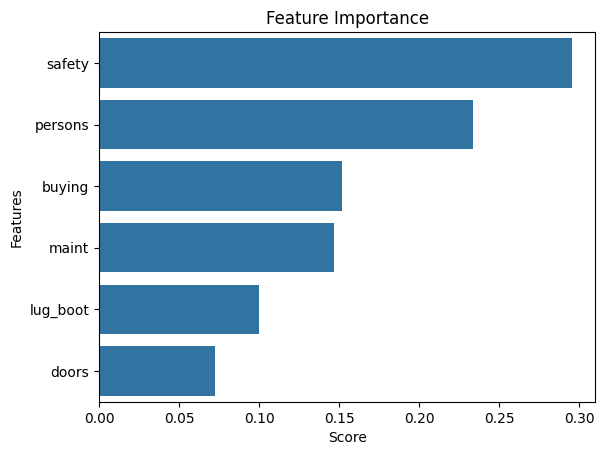

In [71]:
sns.barplot(x=feature_scores, y=feature_scores.index)
plt.xlabel('Score')
plt.ylabel('Features')
plt.title("Feature Importance")
plt.show()

# **17. Construir o modelo Random Forest com características selecionadas** <a class="anchor" id="17"></a>

[Índice](#0.1)

Agora, removerei a característica menos importante, `doors`, do modelo, reconstruirei o modelo e verificarei seu impacto na precisão.


In [72]:
X = df.drop(['class','doors'], axis=1)
y = df['class']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.33, random_state = 42)

In [73]:
encoder = ce.OrdinalEncoder(cols=['buying', 'maint', 'persons', 'lug_boot', 'safety'])
X_train = encoder.fit_transform(X_train)
X_test = encoder.transform(X_test)

In [74]:
# instanciar o modelo Random Forest classifier
rfc = RandomForestClassifier(n_estimators=10,random_state=0)

# KFold cross-validation com 5 folds
kf = KFold(n_splits=5, shuffle=True, random_state=0)

# Avaliando o modelo com cross-validation (usando acurácia)
cv_scores = cross_val_score(rfc, X_train, y_train, cv=kf, scoring='accuracy')

print("Acurácias em cada fold:", cv_scores)
print("Acurácia média (cross-validation): {:.4f}".format(cv_scores.mean()))


# ajustar o modelo (fit the model)
rfc.fit(X_train, y_train)

Acurácias em cada fold: [0.93103448 0.9612069  0.94372294 0.92640693 0.90909091]
Acurácia média (cross-validation): 0.9343


,n_estimators,10
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [75]:
y_pred = rfc.predict(X_test)

print('Acurácia do modelo com 10 árvores: {0:0.4f}'.format(accuracy_score(y_test, y_pred)))
print('Precisão do modelo com 10 árvores: {0:0.4f}'.format(precision_score(y_test, y_pred, average='weighted')))
print('Recall do modelo com 10 árvores: {0:0.4f}'.format(recall_score(y_test, y_pred, average='weighted')))
print('F1-score do modelo com 10 árvores: {0:0.4f}'.format(f1_score(y_test, y_pred, average='weighted')))

Acurácia do modelo com 10 árvores: 0.9264
Precisão do modelo com 10 árvores: 0.9324
Recall do modelo com 10 árvores: 0.9264
F1-score do modelo com 10 árvores: 0.9282


In [ ]:
y_test_bin = label_binarize(y_test, classes=np.unique(y_test))
y_pred_proba = rfc.predict_proba(X_test)

auc_roc = roc_auc_score(y_test_bin, y_pred_proba, average='weighted', multi_class='ovr')
print('AUC-ROC do modelo com 10 árvores: {0:0.4f}'.format(auc_roc))
print('Índice de Gini do modelo com 10 árvores: {0:0.4f}'.format(2 * auc_roc - 1))

AUC-ROC do modelo com o critério índice de Gini: 0.9834
Índice de Gini do modelo com o critério índice de Gini: 0.9667


In [76]:
# instanciar o modelo Random Forest classifier
rfc_100 = RandomForestClassifier(n_estimators=100,random_state=0)

# KFold cross-validation com 5 folds
kf = KFold(n_splits=5, shuffle=True, random_state=0)

# Avaliando o modelo com cross-validation (usando acurácia)
cv_scores = cross_val_score(rfc_100, X_train, y_train, cv=kf, scoring='accuracy')

print("Acurácias em cada fold:", cv_scores)
print("Acurácia média (cross-validation): {:.4f}".format(cv_scores.mean()))


# ajustar o modelo (fit the model)
rfc_100.fit(X_train, y_train)

Acurácias em cada fold: [0.90948276 0.9612069  0.95238095 0.92640693 0.90909091]
Acurácia média (cross-validation): 0.9317


,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [77]:
y_pred_100 = rfc_100.predict(X_test)
print('Acurácia do modelo com 100 árvores: {0:0.4f}'.format(accuracy_score(y_test, y_pred_100)))
print('Precisão do modelo com 100 árvores: {0:0.4f}'.format(precision_score(y_test, y_pred_100, average='weighted')))
print('Recall do modelo com 100 árvores: {0:0.4f}'.format(recall_score(y_test, y_pred_100, average='weighted')))
print('F1-score do modelo com 100 árvores: {0:0.4f}'.format(f1_score(y_test, y_pred_100, average='weighted')))

Acurácia do modelo com 100 árvores: 0.9264
Precisão do modelo com 100 árvores: 0.9333
Recall do modelo com 100 árvores: 0.9264
F1-score do modelo com 100 árvores: 0.9281


In [82]:
y_test_bin = label_binarize(y_train, classes=np.unique(y_train))
y_pred_proba = rfc_100.predict_proba(X_train)

auc_roc = roc_auc_score(y_test_bin, y_pred_proba, average='weighted', multi_class='ovr')
print('AUC-ROC do modelo com 100 árvores: {0:0.4f}'.format(auc_roc))
print('Índice de Gini do modelo com 100 árvores: {0:0.4f}'.format(2 * auc_roc - 1))

AUC-ROC do modelo com 100 árvores: 0.9982
Índice de Gini do modelo com 100 árvores: 0.9963


Removi a variável doors do modelo, reconstruí e verifiquei sua precisão. A precisão do modelo com a variável doors removida é 0,9264. A precisão do modelo com todas as variáveis consideradas é 0,9247. Assim, podemos observar que a precisão do modelo melhorou com a remoção da variável doors.

Além disso, a segunda variável menos importante é lug_boot. Quando a removi do modelo e reconstruí, a precisão encontrada foi 0,8546. Houve uma queda significativa na precisão. Por isso, não a removerei do modelo.

# **18. Matriz de Confusão** <a class="anchor" id="18"></a>

[Índice](#0.1)

A matriz de confusão é uma ferramenta para resumir o desempenho de um algoritmo de classificação. Ela nos dá uma visão clara do desempenho do modelo de classificação e dos tipos de erros cometidos pelo modelo. A matriz apresenta um resumo das previsões corretas e incorretas, divididas por categoria. Esse resumo é representado em forma de tabela.

Quatro tipos de resultados são possíveis ao avaliar o desempenho de um modelo de classificação. Esses quatro resultados são descritos a seguir:

**Verdadeiros Positivos (VP)** – Ocorrem quando prevemos que uma observação pertence a uma determinada classe e ela realmente pertence a essa classe.

**Verdadeiros Negativos (VN)** – Ocorrem quando prevemos que uma observação não pertence a uma determinada classe e ela realmente não pertence a essa classe.

**Falsos Positivos (FP)** – Ocorrem quando prevemos que uma observação pertence a uma determinada classe, mas na verdade ela não pertence. Esse tipo de erro é chamado de **Erro Tipo I**.

**Falsos Negativos (FN)** – Ocorrem quando prevemos que uma observação não pertence a uma determinada classe, mas na verdade ela pertence. Esse é um erro muito grave e é chamado de **Erro Tipo II**.

Esses quatro resultados são resumidos em uma matriz de confusão, apresentada a seguir.


In [78]:
# Imprimir a Matriz de Confusão e dividi-la em quatro partes

from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_100)

print('Confusion matrix\n\n', cm)

Confusion matrix

 [[104  12  10   3]
 [  0  18   0   2]
 [ 10   0 387   0]
 [  3   2   0  20]]


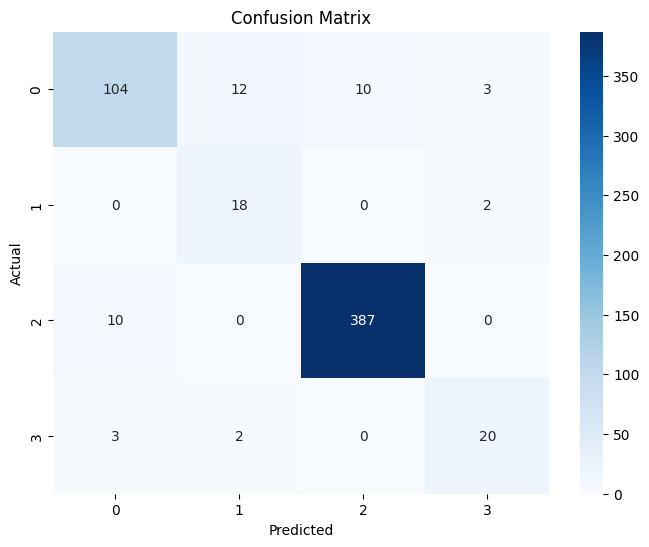

In [79]:
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

# **19. Relatório de Classificação** <a class="anchor" id="19"></a>

[Índice](#0.1)

O **relatório de classificação** é outra forma de avaliar o desempenho de um modelo de classificação. Ele exibe as métricas de **precisão** (*precision*), **revocação** (*recall*), **f1-score** e **suporte** (*support*) para o modelo. Esses termos serão descritos mais adiante.

Podemos imprimir um relatório de classificação da seguinte forma:


In [81]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_100))

              precision    recall  f1-score   support

         acc       0.89      0.81      0.85       129
        good       0.56      0.90      0.69        20
       unacc       0.97      0.97      0.97       397
       vgood       0.80      0.80      0.80        25

    accuracy                           0.93       571
   macro avg       0.81      0.87      0.83       571
weighted avg       0.93      0.93      0.93       571



# **20. Resultados e conclusão** <a class="anchor" id="20"></a>

[Índice](#0.1)

1. Neste projeto, construí um Classificador Random Forest para prever a segurança do carro. Desenvolvi dois modelos, um com 10 árvores de decisão e outro com 100 árvores de decisão.
2. A pontuação de precisão do modelo com 10 árvores de decisão é 0,9247, enquanto com 100 árvores de decisão é 0,9457. Portanto, como esperado, a precisão aumenta com o número de árvores de decisão no modelo.
3. Utilizei o modelo Random Forest para identificar apenas as características importantes, construir o modelo com essas características e analisar o impacto na precisão. A característica mais importante é `safety` e a menos importante é `doors`.
4. Removi a variável `doors` do modelo, reconstruí e verifiquei sua precisão. A precisão do modelo com a variável `doors` removida é 0,9264. A precisão do modelo com todas as variáveis consideradas é 0,9247. Assim, podemos observar que a precisão do modelo melhorou com a remoção da variável `doors`.
5. A segunda variável menos importante é `lug_boot`. Quando a removi do modelo e o reconstruí, a precisão encontrada foi 0,8546. Houve uma queda significativa na precisão. Por isso, não a removi do modelo.
6. A matriz de confusão e o relatório de classificação são outras ferramentas para visualizar o desempenho do modelo. Eles apresentaram um bom desempenho.
